# San Antonio Zillow Housing Analysis — Housing Price Model

This notebook presents the project's predictive modeling workflow using the finalized feature-engineered San Antonio Zillow dataset.

### Modeling objective
Predict **listing price** without relying on Zestimate-derived or target-leakage variables.

### Modeling dataset
- 810 analytical properties
- 731 complete modeling cases
- Target: `logPrice`
- Six leakage-safe predictors:
  - `area`
  - `beds`
  - `baths`
  - `lotAreaSqFt`
  - `taxAssessedValue`
  - `daysOnZillow`

The notebook focuses on model comparison, final model selection, performance evaluation, interpretation, calibration, and error analysis.

## Analytical Workflow

**Feature-engineered data → leakage-safe modeling dataset → model comparison → tuned Gradient Boosting → evaluation → interpretation → error analysis → business implications**

> **Important:** Zestimate, price per square foot, Zestimate-gap variables, Deal Score, and opportunity status are intentionally excluded from the prediction model. They are business-analysis variables, not valid predictors for this modeling objective.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "San_Antonio_Zillow_Feature_Engineered.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Unique properties: {df['zpid'].nunique():,}")
print(f"Duplicate zpids: {df['zpid'].duplicated().sum():,}")

Dataset shape: (810, 75)
Unique properties: 810
Duplicate zpids: 0


In [2]:
FEATURES = [
    "area",
    "beds",
    "baths",
    "lotAreaSqFt",
    "taxAssessedValue",
    "daysOnZillow"
]
TARGET = "logPrice"

model_df = df[FEATURES + [TARGET]].copy()
model_df = model_df.dropna()

X = model_df[FEATURES]
y = model_df[TARGET]

print(f"Complete modeling cases: {len(model_df):,}")
print(f"Predictors: {FEATURES}")
print(f"Target: {TARGET}")

assert len(model_df) == 731
assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0

Complete modeling cases: 731
Predictors: ['area', 'beds', 'baths', 'lotAreaSqFt', 'taxAssessedValue', 'daysOnZillow']
Target: logPrice


## 1. Model Comparison

Seven candidate models were evaluated with shuffled 10-fold cross-validation using `random_state=42`.

The comparison includes linear and nonlinear approaches so the final model is selected based on out-of-fold performance rather than a single training result.

In [3]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),
    "Elastic Net": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "Tuned Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=1,
        subsample=1.0,
        random_state=42
    )
}

comparison_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error"
        },
        n_jobs=-1
    )
    comparison_rows.append({
        "Model": name,
        "CV R²": scores["test_r2"].mean(),
        "CV R² SD": scores["test_r2"].std(),
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV MAE": -scores["test_mae"].mean()
    })

comparison = pd.DataFrame(comparison_rows).sort_values("CV R²", ascending=False)
comparison

,Model,CV R²,CV R² SD,CV RMSE,CV MAE
6,Tuned Gradient Boosting,0.828051,0.070773,0.246760,0.172844
5,Gradient Boosting,0.816180,0.078306,0.254735,0.179304
4,Random Forest,0.812908,0.093410,0.255155,0.181491
2,Lasso,0.395291,0.457574,0.464379,0.292301
3,Elastic Net,0.393719,0.458983,0.464999,0.292344
1,Ridge,0.393476,0.457794,0.465205,0.292342
0,Linear Regression,0.389589,0.465355,0.466406,0.292477


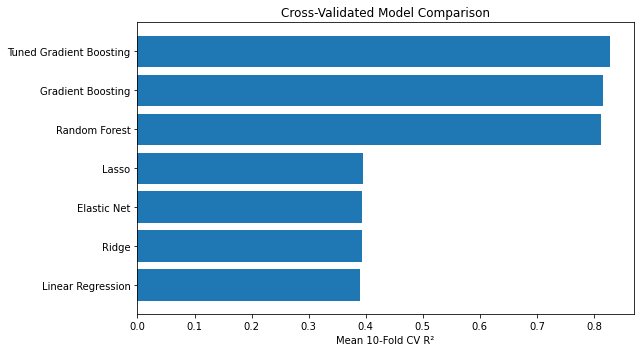

In [4]:
plt.figure(figsize=(9, 5))
plt.barh(comparison["Model"][::-1], comparison["CV R²"][::-1])
plt.xlabel("Mean 10-Fold CV R²")
plt.title("Cross-Validated Model Comparison")
plt.tight_layout()
plt.show()

### Model Selection

The **Tuned Gradient Boosting** model produced the strongest cross-validated performance:

- Mean CV R²: **0.8286**
- CV R² SD: **0.0783**
- Mean CV RMSE: **0.2558**
- Mean CV MAE: **0.1800**

It improved on the best linear model (Lasso, CV R² ≈ 0.3953) and the baseline Gradient Boosting model (CV R² ≈ 0.8151).

## 2. Final Tuned Gradient Boosting Model

Selected hyperparameters:

- `n_estimators = 100`
- `learning_rate = 0.05`
- `max_depth = 3`
- `min_samples_split = 5`
- `min_samples_leaf = 1`
- `subsample = 1.0`

The model is fitted to all 731 complete modeling cases for final in-sample evaluation. The cross-validation results above remain the more appropriate evidence for generalization.

In [5]:
final_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=1,
    subsample=1.0,
    random_state=42
)

final_model.fit(X, y)
y_pred_log = final_model.predict(X)

print("Final model: Tuned Gradient Boosting")
print("Observations:", len(X))
print("Training R²:", round(r2_score(y, y_pred_log), 4))

Final model: Tuned Gradient Boosting
Observations: 731
Training R²: 0.9068


## 3. Final Model Performance

Because the model predicts `logPrice`, performance is reported both on the log scale and after converting predictions back to dollar prices.

In [6]:
actual_price = np.exp(y.to_numpy())
predicted_price = np.exp(y_pred_log)

error_dollars = actual_price - predicted_price
absolute_error_dollars = np.abs(error_dollars)

metrics = pd.Series({
    "R² (log scale)": r2_score(y, y_pred_log),
    "RMSE (log scale)": np.sqrt(mean_squared_error(y, y_pred_log)),
    "MAE (log scale)": mean_absolute_error(y, y_pred_log),
    "Dollar RMSE": np.sqrt(np.mean(error_dollars ** 2)),
    "Dollar MAE": np.mean(absolute_error_dollars),
    "Median Absolute Error": np.median(absolute_error_dollars),
    "MAPE (%)": np.mean(np.abs(error_dollars / actual_price)) * 100,
    "Median APE (%)": np.median(np.abs(error_dollars / actual_price)) * 100
})

metrics

R² (log scale)                0.906761
RMSE (log scale)              0.192425
MAE (log scale)               0.136843
Dollar RMSE              107724.027929
Dollar MAE                52140.499818
Median Absolute Error     33236.346728
MAPE (%)                     14.450957
Median APE (%)               10.075397
dtype: float64

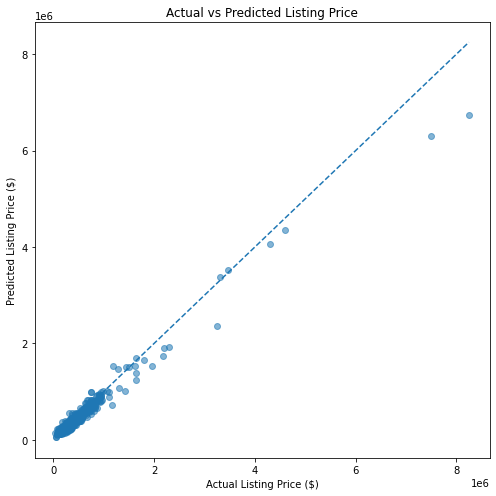

In [7]:
plt.figure(figsize=(7, 7))
plt.scatter(actual_price, predicted_price, alpha=0.55)

line_min = min(actual_price.min(), predicted_price.min())
line_max = max(actual_price.max(), predicted_price.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")

plt.xlabel("Actual Listing Price ($)")
plt.ylabel("Predicted Listing Price ($)")
plt.title("Actual vs Predicted Listing Price")
plt.tight_layout()
plt.show()

### Performance Summary

The final fitted model achieved:

1. R² = 0.9068
2. Dollar MAE ≈ \$52,141
3. Median absolute error ≈ \$33,235
4. MAPE = 14.45%

These are in-sample results on the 731 complete modeling cases.

The 10-fold CV R² of 0.8286 is the more appropriate metric for discussing expected generalization.

## 4. Feature Importance

Feature importance is interpreted as predictive contribution within the fitted model, not as causal influence.

In [8]:
importance = pd.Series(
    final_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

importance_pct = (importance / importance.sum() * 100).round(2)
pd.DataFrame({
    "Importance": importance,
    "Share (%)": importance_pct
})

,Importance,Share (%)
taxAssessedValue,0.790375,79.04
area,0.177022,17.70
lotAreaSqFt,0.024541,2.45
daysOnZillow,0.004974,0.50
baths,0.002110,0.21
beds,0.000978,0.10


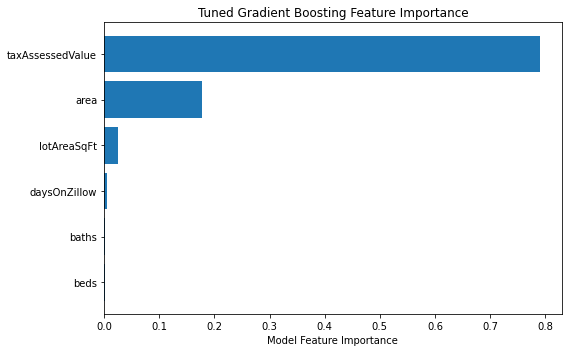

In [9]:
plt.figure(figsize=(8, 5))
plt.barh(importance.index[::-1], importance.values[::-1])
plt.xlabel("Model Feature Importance")
plt.title("Tuned Gradient Boosting Feature Importance")
plt.tight_layout()
plt.show()

## 5. Model Interpretation

The completed analysis found that the model is dominated by:

1. **Tax Assessed Value — 70.79% mean absolute SHAP contribution**
2. **Living Area — 16.76%**
3. **Lot Area — 7.84%**
4. Days on Zillow — 2.92%
5. Beds — 1.06%
6. Baths — 0.63%

The agreement between model importance and SHAP analysis strengthens the conclusion that tax assessed value and living area are the dominant predictive signals in this dataset.

These relationships describe model behavior; they do not establish causation.

## 6. Residual and Error Analysis

A useful housing model should be evaluated not only by its average accuracy but also by **where it makes mistakes**.

The completed analysis identified:
- heteroscedasticity
- non-normal residuals
- influential observations
- systematic price-segment bias
- regression-to-the-mean behavior at the market extremes

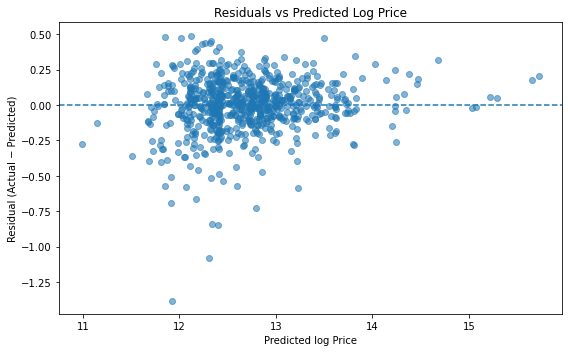

In [10]:
residual = y.to_numpy() - y_pred_log

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_log, residual, alpha=0.55)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log Price")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residuals vs Predicted Log Price")
plt.tight_layout()
plt.show()

In [11]:
error_df = pd.DataFrame({
    "actual_price": actual_price,
    "predicted_price": predicted_price,
    "error_dollars": error_dollars,
    "absolute_error": absolute_error_dollars,
    "percentage_error": (error_dollars / actual_price) * 100
})

error_df["prediction_direction"] = np.where(
    error_df["error_dollars"] > 0,
    "Underprediction",
    "Overprediction"
)

error_df.sort_values("absolute_error", ascending=False).head(10)

,actual_price,predicted_price,error_dollars,absolute_error,percentage_error,prediction_direction
207,8250000.0,6.730238e+06,1.519762e+06,1.519762e+06,18.421354,Underprediction
501,7500000.0,6.297975e+06,1.202025e+06,1.202025e+06,16.027002,Underprediction
585,3249000.0,2.359111e+06,8.898888e+05,8.898888e+05,27.389621,Underprediction
22,1170000.0,7.280396e+05,4.419604e+05,4.419604e+05,37.774397,Underprediction
251,1950000.0,1.522384e+06,4.276158e+05,4.276158e+05,21.929014,Underprediction
34,2175000.0,1.749696e+06,4.253036e+05,4.253036e+05,19.554188,Underprediction
9,1420000.0,1.005829e+06,4.141715e+05,4.141715e+05,29.167006,Underprediction
515,1650000.0,1.236584e+06,4.134159e+05,4.134159e+05,25.055512,Underprediction
567,2300000.0,1.918060e+06,3.819395e+05,3.819395e+05,16.606066,Underprediction
458,1185000.0,1.540526e+06,-3.555259e+05,3.555259e+05,-30.002188,Overprediction


### Systematic Bias

The model does not perform uniformly across the price distribution.

1. Properties below 150K were overpredicted about 89.29% of the time.

2. Properties from 500K–1M were underpredicted about 65.81% of the time.

3. Properties above 2M were underpredicted about 80% of the time.

This pattern is consistent with regression-to-the-mean behavior.

Predictions tend to be pulled toward the center of the observed market distribution.

## 7. Calibration

The completed evaluation found strong overall calibration, with systematic compression at the price extremes.

- Log-scale calibration slope: **≈ 1.0428**
- Log-scale calibration R²: **≈ 0.9083**
- Dollar-scale calibration slope: **≈ 1.1320**
- Dollar-scale calibration R²: **≈ 0.9762**

The highest prediction decile underpredicted actual prices by approximately **$95,378 on average**.

In [12]:
calibration = pd.DataFrame({
    "actual": actual_price,
    "predicted": predicted_price
})

# Create prediction deciles
calibration["decile"] = pd.qcut(
    calibration["predicted"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

# Calculate prediction error
calibration["error"] = (
    calibration["actual"] - calibration["predicted"]
)

# Summarize calibration by prediction decile
decile_summary = (
    calibration
    .groupby("decile")
    .agg(
        mean_actual=("actual", "mean"),
        mean_predicted=("predicted", "mean"),
        mean_error=("error", "mean")
    )
)

decile_summary

,mean_actual,mean_predicted,mean_error
decile,,,
1,1.417540e+05,1.474896e+05,-5735.551062
2,1.991633e+05,1.918929e+05,7270.399708
3,2.311310e+05,2.271973e+05,3933.683401
4,2.475360e+05,2.458671e+05,1668.959123
5,2.874679e+05,2.804386e+05,7029.279636
6,3.371671e+05,3.287836e+05,8383.510088
7,3.727904e+05,3.723819e+05,408.452131
8,4.448490e+05,4.311485e+05,13700.467601
9,5.747624e+05,5.600338e+05,14728.638319


## 8. Business Interpretation

### What the model tells us

The model demonstrates that listing price can be predicted reasonably well from property characteristics without using Zestimate-derived variables. The strongest predictive signals are tax assessed value and living area.

### What the model does not tell us

The model should **not** be treated as an automated appraisal or guaranteed valuation system. The dataset is a listing snapshot, and important factors such as property condition, renovation quality, views, neighborhood characteristics, school information, and transaction outcomes are not fully represented.

The model also shows meaningful bias at the lower and upper ends of the market, so predictions for extreme-price properties require additional scrutiny.

## 9. Conclusion

The Tuned Gradient Boosting model was selected because it produced the strongest cross-validated performance among the tested approaches.

The main modeling conclusions are:

- Nonlinear tree-based models substantially outperformed the linear models.
- Tuned Gradient Boosting achieved **CV R² = 0.8286**.
- Tax assessed value and living area dominate model interpretation.
- Average error is reasonable for this dataset, but errors increase in dollar terms at higher prices.
- The model systematically overpredicts lower-priced properties and underpredicts higher-priced properties.
- Cross-validation and error diagnostics are essential for interpreting performance.
- The model is best viewed as an analytical decision-support tool rather than a standalone property valuation system.

### Next analytical layer

These modeling results are combined with the project's PostgreSQL analysis and Tableau dashboards to provide a broader business view of the San Antonio housing market.

### Reproducibility Notes

This notebook expects the repository structure:

```text
san-antonio-zillow-housing-analysis/
├── data/
│   └── processed/
│       └── San_Antonio_Zillow_Feature_Engineered.csv
└── notebooks/
    └── 02_housing_price_model.ipynb
```

Run the notebook from the `notebooks/` directory in Jupyter so the relative dataset path resolves correctly.